<a href="https://colab.research.google.com/github/Lornatt88/maai901-vision-project/blob/main/notebooks/01_data_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Downloading the dataset into Colab**

In [1]:
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset saved at:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset saved at: /kaggle/input/skin-cancer-mnist-ham10000


### **Looking at what we downloaded**

In [2]:
import os
import pandas as pd

print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "HAM10000_metadata.csv"))
print(df.shape)
print(df.head())
print(df["dx"].value_counts())

['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']
(10015, 7)
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


### **Keeping only the 4 classes I want to use and find each image**

In [3]:
keep = ["nv", "bkl", "mel", "bcc"]
df4 = df[df["dx"].isin(keep)].copy()

image_paths = {}
for folder in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
    folder_path = os.path.join(path, folder)
    for file in os.listdir(folder_path):
        image_id = file.replace(".jpg", "")
        image_paths[image_id] = os.path.join(folder_path, file)

df4["path"] = df4["image_id"].map(image_paths)

print(df4.shape)
print("Missing images:", df4["path"].isna().sum())
print(df4["dx"].value_counts())
print("Unique lesions per class:")
print(df4.groupby("dx")["lesion_id"].nunique())

(9431, 8)
Missing images: 0
dx
nv     6705
mel    1113
bkl    1099
bcc     514
Name: count, dtype: int64
Unique lesions per class:
dx
bcc     327
bkl     727
mel     614
nv     5403
Name: lesion_id, dtype: int64


### **Balancing the classes and splitting the data**

In [4]:
from sklearn.model_selection import train_test_split

lesions = df4.groupby("lesion_id")["dx"].first().reset_index()

nv = lesions[lesions["dx"] == "nv"].sample(n=750, random_state=42)
others = lesions[lesions["dx"] != "nv"]
lesions_bal = pd.concat([nv, others])

train_les, temp_les = train_test_split(lesions_bal, test_size=0.30, stratify=lesions_bal["dx"], random_state=42)
val_les, test_les = train_test_split(temp_les, test_size=0.50, stratify=temp_les["dx"], random_state=42)

train_df = df4[df4["lesion_id"].isin(train_les["lesion_id"])]
val_df = df4[df4["lesion_id"].isin(val_les["lesion_id"])]
test_df = df4[df4["lesion_id"].isin(test_les["lesion_id"])]

for name, d in [("TRAIN", train_df), ("VALIDATION", val_df), ("TEST", test_df)]:
    print(name, len(d), "images")
    print(d["dx"].value_counts(), "\n")

TRAIN 2566 images
dx
bkl    772
mel    767
nv     652
bcc    375
Name: count, dtype: int64 

VALIDATION 542 images
dx
mel    178
bkl    156
nv     132
bcc     76
Name: count, dtype: int64 

TEST 544 images
dx
bkl    171
mel    168
nv     142
bcc     63
Name: count, dtype: int64 



### **Double-checking and saving the split**

**here we are:**
- Checking no spot leaked into two groups. This should print zeros, proving the split is clean.

- Saving the three lists to Google Drive. Saving to Drive means every future notebook uses the exact same split, which keeps our three models' comparison fair.

In [6]:
print("Train & Val overlap:", len(set(train_df["lesion_id"]) & set(val_df["lesion_id"])))
print("Train & Test overlap:", len(set(train_df["lesion_id"]) & set(test_df["lesion_id"])))
print("Val & Test overlap:", len(set(val_df["lesion_id"]) & set(test_df["lesion_id"])))

from google.colab import drive
drive.mount("/content/drive")

save_dir = "/content/drive/MyDrive/maai901_skin"
os.makedirs(save_dir, exist_ok=True)

train_df.to_csv(os.path.join(save_dir, "train.csv"), index=False)
val_df.to_csv(os.path.join(save_dir, "val.csv"), index=False)
test_df.to_csv(os.path.join(save_dir, "test.csv"), index=False)

print("Saved:", os.listdir(save_dir))

Train & Val overlap: 0
Train & Test overlap: 0
Val & Test overlap: 0
Mounted at /content/drive
Saved: ['train.csv', 'val.csv', 'test.csv']


### **Looking at sample images**

Benign = harmless. Not cancer. It won't spread to other parts of the body.

Malignant = cancerous. It can grow and spread, so it needs treatment.

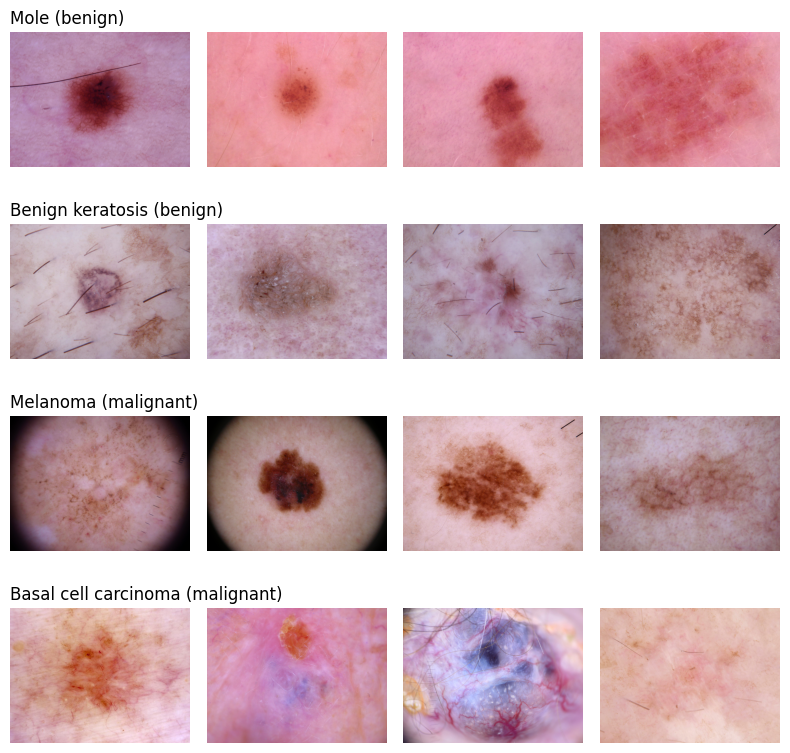

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

names = {
    "nv": "Mole (benign)",
    "bkl": "Benign keratosis (benign)",
    "mel": "Melanoma (malignant)",
    "bcc": "Basal cell carcinoma (malignant)",
}

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for r, (code, label) in enumerate(names.items()):
    samples = train_df[train_df["dx"] == code].sample(4, random_state=42)
    for c, (_, row) in enumerate(samples.iterrows()):
        axes[r, c].imshow(Image.open(row["path"]))
        axes[r, c].axis("off")
    axes[r, 0].set_title(label, loc="left", fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "sample_images.png"), dpi=150)
plt.show()